In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# Контрольная работа:
# Датасет Used Cars Dataset
# https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data
# 1. Удалите столбец county
# 2. Удалите строки с пустым year
# 3. Заполните пропущенные значения в столбце odometer медианой.
# 4. Сгруппируйте данные по типу кузова (type) и посчитайте среднюю стоимость (price).
# 5. Сгруппируйте данные по типу топлива (fuel). Для каждого типа посчитайте:
#   - Медианную стоимость (price)
#   - Средний пробег (odometer)
#   - Суммарную стоимость (price)
# 6. Создайте сводную таблицу, которая показывает среднюю стоимость (price) в зависимости от типа кузова (type) и типа привода (drive).
# 7. Извлеките числовое занчение из cylinders. Создайте столбец cylinders_num
#   - (Можно использовать регулярного выражения для этого: r'(\d+)')
# 8. Постройте ящик с усами стоимости автомобиля (price) у которых цена ниже 50 тыс.
# 9. Постройте столбчатую диаграмму медианной стоимости (price) по типу кузова (type).
# 10. Создайте датафрейм:
#   +-----------------+---------------+
#   +  manufacturer   +  country      +
#   +-----------------+---------------+  
#   +  ford           +  USA          +   
#   +  chevrolet      +  USA          +   
#   +  toyota         +  Japan        +     
#   +  honda          +  Japan        +     
#   +  jeep           +  USA          +   
#   +  nissan         +  Japan        +     
#   +  ram            +  USA          +   
#   +  gmc            +  USA          +   
#   +  bmw            +  Germany      +       
#   +  mercedes-benz  +  Germany      +       
#   +  hyundai        +  South Korea  +           
#   +  subaru         +  Japan        +     
#   +  volkswagen     +  Germany      +       
#   +  kia            +  South Korea  +           
#   +-----------------+---------------+
#   - Объедините (merge) ваш основной DataFrame с этой новой таблицей по столбцу manufacturer. Убедитесь, что в итоговой таблице появился столбец country.

In [4]:
df = pd.read_csv('../data/raw/vehicles.csv')

In [5]:
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [7]:
# 1. Удалите столбец county
df = df.drop(columns=['county'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [9]:
# 2. Удалите строки с пустым year
df = df.dropna(subset=['year'], ignore_index=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425675 entries, 0 to 425674
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            425675 non-null  int64  
 1   url           425675 non-null  object 
 2   region        425675 non-null  object 
 3   region_url    425675 non-null  object 
 4   price         425675 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409228 non-null  object 
 7   model         420466 non-null  object 
 8   condition     252766 non-null  object 
 9   cylinders     248084 non-null  object 
 10  fuel          422930 non-null  object 
 11  odometer      421344 non-null  float64
 12  title_status  417745 non-null  object 
 13  transmission  423187 non-null  object 
 14  VIN           264701 non-null  object 
 15  drive         295408 non-null  object 
 16  size          120519 non-null  object 
 17  type          333008 non-null  object 
 18  pain

In [13]:
# 3. Заполните пропущенные значения в столбце odometer медианой.
median_odometer = df['odometer'].median()
df['odometer'] = df['odometer'].fillna(median_odometer)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425675 entries, 0 to 425674
Data columns (total 25 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            425675 non-null  int64  
 1   url           425675 non-null  object 
 2   region        425675 non-null  object 
 3   region_url    425675 non-null  object 
 4   price         425675 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409228 non-null  object 
 7   model         420466 non-null  object 
 8   condition     252766 non-null  object 
 9   cylinders     248084 non-null  object 
 10  fuel          422930 non-null  object 
 11  odometer      425675 non-null  float64
 12  title_status  417745 non-null  object 
 13  transmission  423187 non-null  object 
 14  VIN           264701 non-null  object 
 15  drive         295408 non-null  object 
 16  size          120519 non-null  object 
 17  type          333008 non-null  object 
 18  pain

In [15]:
df['cylinders'].value_counts()

cylinders
6 cylinders     93700
4 cylinders     77293
8 cylinders     71776
5 cylinders      1712
10 cylinders     1448
other            1298
3 cylinders       648
12 cylinders      209
Name: count, dtype: int64

In [16]:
# 7. Извлеките числовое занчение из cylinders. Создайте столбец cylinders_num
#   - (Можно использовать регулярного выражения для этого: r'(\d+)')
# df['cylinders_num'] = pd.to_numeric(df['cylinders'].str.split(' ', expand=True)[0],errors='coerce')
df['cylinders_num'] = pd.to_numeric(df['cylinders'].str.extract(r'(\d+)')[0])

In [17]:
df[['cylinders', 'cylinders_num']]

,cylinders,cylinders_num
0,8 cylinders,8.0
1,8 cylinders,8.0
2,8 cylinders,8.0
3,8 cylinders,8.0
4,6 cylinders,6.0
...,...,...
425670,6 cylinders,6.0
425671,NaN,NaN
425672,NaN,NaN
425673,6 cylinders,6.0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425675 entries, 0 to 425674
Data columns (total 26 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             425675 non-null  int64  
 1   url            425675 non-null  object 
 2   region         425675 non-null  object 
 3   region_url     425675 non-null  object 
 4   price          425675 non-null  int64  
 5   year           425675 non-null  float64
 6   manufacturer   409228 non-null  object 
 7   model          420466 non-null  object 
 8   condition      252766 non-null  object 
 9   cylinders      248084 non-null  object 
 10  fuel           422930 non-null  object 
 11  odometer       425675 non-null  float64
 12  title_status   417745 non-null  object 
 13  transmission   423187 non-null  object 
 14  VIN            264701 non-null  object 
 15  drive          295408 non-null  object 
 16  size           120519 non-null  object 
 17  type           333008 non-nul

In [21]:
# 4. Сгруппируйте данные по типу кузова (type) и посчитайте среднюю стоимость (price).
sum_sales_by_region = df.groupby('type')['price'].mean().sort_values(ascending=False)
sum_sales_by_region

type
pickup         145559.578464
SUV             34450.938063
truck           29383.577993
other           24743.587517
coupe           21919.163391
convertible     19982.749029
van             17179.710536
sedan           15934.249885
offroad         15813.093596
hatchback       14383.255848
bus             14105.617021
wagon           13273.909683
mini-van         9234.087668
Name: price, dtype: float64

In [22]:
# 5. Сгруппируйте данные по типу топлива (fuel). Для каждого типа посчитайте:
#   - Медианную стоимость (price)
#   - Средний пробег (odometer)
#   - Суммарную стоимость (price)
stats_by_fuel = df.groupby('fuel').agg(
    median_price=('price', 'median'),
    mean_odometer=('odometer', 'mean'),
    total_price=('price', 'sum'),
)
stats_by_fuel

,median_price,mean_odometer,total_price
fuel,,,
diesel,27990.0,136971.765329,3543336406
electric,22499.0,40085.736578,41749029
gas,11995.0,98681.897332,26297830404
hybrid,11995.0,89601.643078,75232320
other,25990.0,58784.963603,2052959524


In [25]:
# 6. Создайте сводную таблицу, которая показывает среднюю стоимость (price) в зависимости от типа кузова (type) и типа привода (drive).
pivot_price = df.pivot_table(values='price', index='type', columns='drive', aggfunc='mean').sort_values('4wd')
pivot_price

drive,4wd,fwd,rwd
type,,,
mini-van,9598.367816,9244.002090,12811.764331
wagon,12716.550496,12251.330242,12050.490506
hatchback,14186.390883,12334.440923,15410.701087
sedan,14615.308664,15402.304277,18303.703707
bus,15563.000000,7500.352941,15825.709343
offroad,16105.071942,7722.727273,11280.416667
SUV,16328.531893,13898.286463,13907.339074
van,18675.975862,14879.349258,18772.121841
convertible,24776.536264,11030.651332,21723.805212


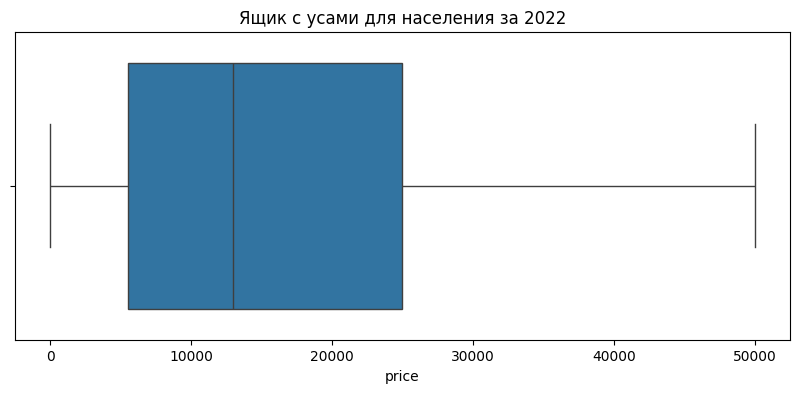

In [26]:
# 8. Постройте ящик с усами стоимости автомобиля (price) у которых цена ниже 50 тыс.
plt.figure(figsize=(10, 4))
plt.title('Ящик с усами для населения за 2022')
sns.boxplot(data=df[df['price']<50_000], x='price')
plt.show()

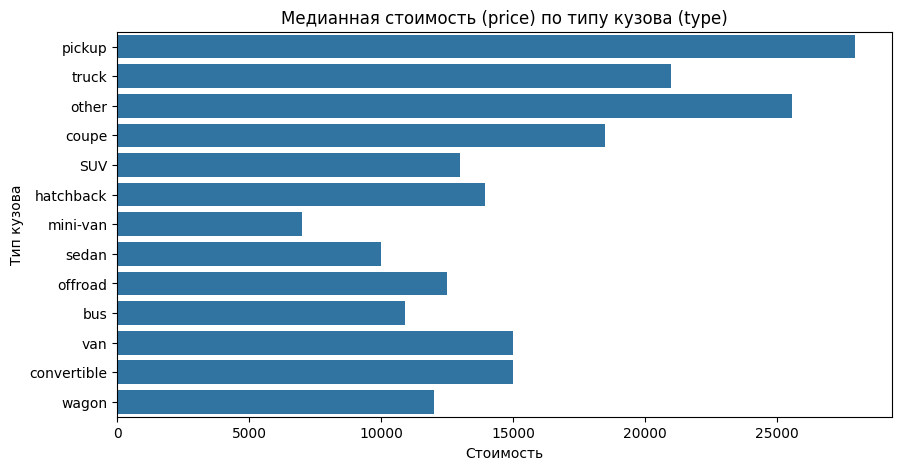

In [27]:
# 9. Постройте столбчатую диаграмму медианной стоимости (price) по типу кузова (type).
plt.figure(figsize=(10, 5))
plt.title('Медианная стоимость (price) по типу кузова (type)')
plt.xlabel('Стоимость')
plt.ylabel('Тип кузова')
sns.barplot(data=df, x='price', y='type', estimator='median', errorbar=None)
plt.show()

In [28]:
# 10. Создайте датафрейм:
#   +-----------------+---------------+
#   +  manufacturer   +  country      +
#   +-----------------+---------------+  
#   +  ford           +  USA          +   
#   +  chevrolet      +  USA          +   
#   +  toyota         +  Japan        +     
#   +  honda          +  Japan        +     
#   +  jeep           +  USA          +   
#   +  nissan         +  Japan        +     
#   +  ram            +  USA          +   
#   +  gmc            +  USA          +   
#   +  bmw            +  Germany      +       
#   +  mercedes-benz  +  Germany      +       
#   +  hyundai        +  South Korea  +           
#   +  subaru         +  Japan        +     
#   +  volkswagen     +  Germany      +       
#   +  kia            +  South Korea  +           
#   +-----------------+---------------+
#   - Объедините (merge) ваш основной DataFrame с этой новой таблицей по столбцу manufacturer. Убедитесь, что в итоговой таблице появился столбец country.
data = {
    'manufacturer': ['ford', 'chevrolet', 'toyota', 'honda', 'jeep', 
                     'nissan', 'ram', 'gmc', 'bmw', 'mercedes-benz', 
                     'hyundai', 'subaru', 'volkswagen', 'kia'],
    'country': ['USA', 'USA', 'Japan', 'Japan', 'USA', 'Japan', 'USA', 
                'USA', 'Germany', 'Germany', 'South Korea', 'Japan', 
                'Germany', 'South Korea']
}
country_origin_df = pd.DataFrame(data)
df_merged = pd.merge(df, country_origin_df, on='manufacturer', how='left')
df_merged[['manufacturer', 'country']]

,manufacturer,country
0,gmc,USA
1,chevrolet,USA
2,chevrolet,USA
3,toyota,Japan
4,ford,USA
...,...,...
425670,nissan,Japan
425671,volvo,NaN
425672,cadillac,NaN
425673,lexus,NaN
